In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("../data/marketing_and_sales.csv")

In [2]:
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   str    
 4   Sales         4566 non-null   float64
dtypes: float64(4), str(1)
memory usage: 178.7 KB


Sur un total de 4572 entrées, TV, Radio, Social Media et Sales ont des valeurs manquantes.

In [4]:
print(df.isnull().sum())

TV              10
Radio            4
Social Media     6
Influencer       0
Sales            6
dtype: int64


Il manque 10 données pour TV, 4 pour Radio, 6 pour Social Medial et Sales

In [5]:
df.describe()

,TV,Radio,Social Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


TV est le canal le plus lourd avec un budget moyen de 54 millions et un max de 100 millions.  
Social Media a une moyenne de 3 millions et le max monte jusqu'à presque 14 millions.  
Radio aussi a un écart important entre la moyenne et le max.

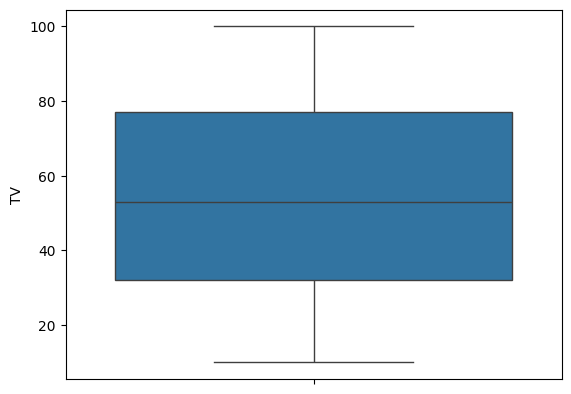

In [6]:
sns.boxplot(y=df["TV"])
plt.show()

TV est symétrique et équilibrée sans aucune valeur aberrante.  
Les budgets sont compris entre 10 et 100 millions avec une concentration entre 32 et 77 millions.

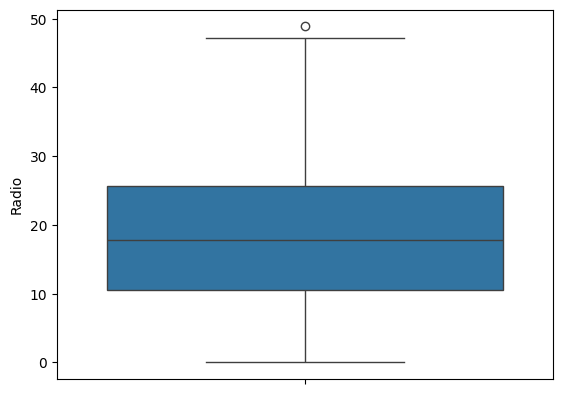

In [7]:
sns.boxplot(y=df["Radio"])
plt.show()

Radio a un Outlier au dessus du seuil IQR.

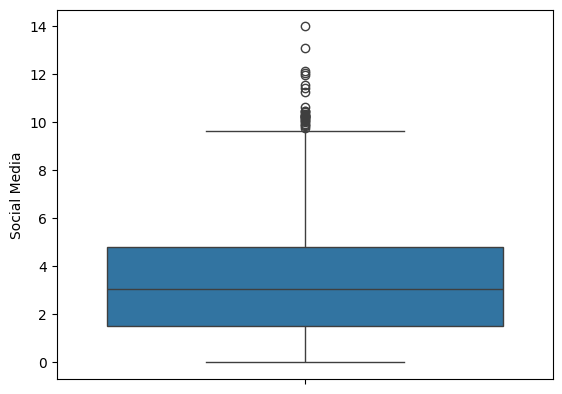

In [8]:
sns.boxplot(y=df["Social Media"])
plt.show()

Social Media a des Outliers entre 10 et 14 millions.

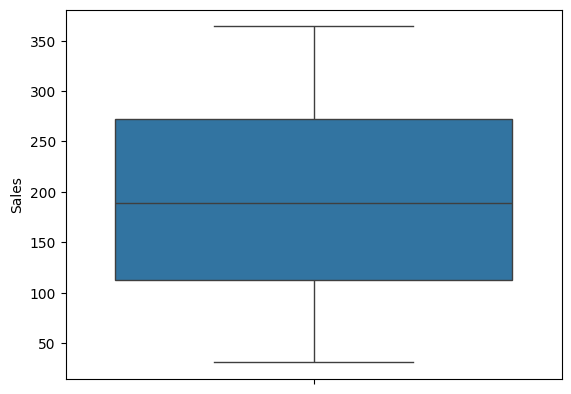

In [9]:
sns.boxplot(y=df["Sales"])
plt.show()

La distribution pour Sales est bonne, symétrique et équilibrée.  
Il y'a une forte dispersion et c'est l'impact réel des budgets.

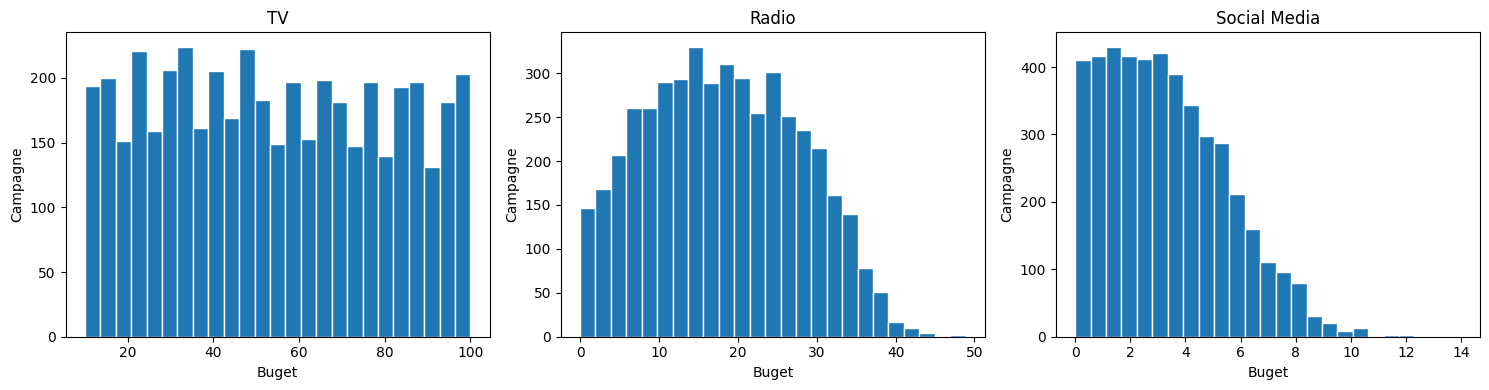

In [15]:
features = ['TV', 'Radio', 'Social Media']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=25, edgecolor='white')
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("Buget")
    axes[i].set_ylabel("Campagne")

plt.tight_layout()
plt.show()

TV : Les budgets sont répartis de façon très régulière entre ~10 et ~100.   
Radio : La majorité des campagnes investissent entre 5 et 25 en Radio, avec une queue qui s'étire vers 50. C'est cohérent avec le boxplot qui montrait 1 outlier à ~49. 
Social Media : Très asymétrique à droite. La majorité des campagnes sont concentrées entre 0 et 5, puis ça chute rapidement.  

*(Pour mieux comprendre (Radio) : il y a environ 330 campagnes marketing qui ont bénéficié d'un budget Radio de 15 millions.)*

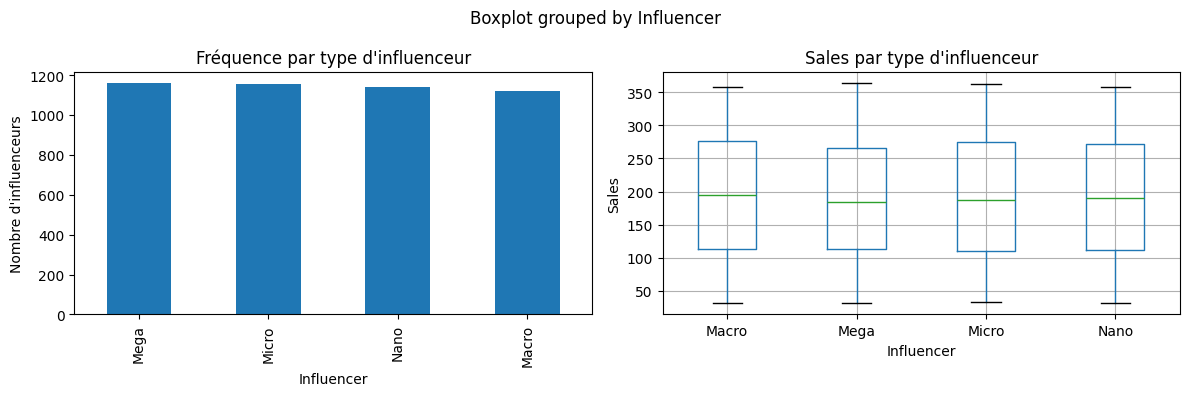

,mean,median,count
Influencer,,,
Macro,195.613601,194.232285,1121
Mega,190.593666,184.167871,1156
Micro,191.809095,187.946693,1152
Nano,191.934304,189.655812,1137


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Influencer'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title("Fréquence par type d'influenceur")
axes[0].set_ylabel("qte de données")

df.boxplot(column='Sales', by='Influencer', ax=axes[1])
axes[1].set_title("Sales par type d'influenceur")
axes[1].set_ylabel("Sales")

plt.tight_layout()
plt.show()

df.groupby('Influencer')['Sales'].agg(['mean', 'median', 'count'])

Les 4 catégories sont équilibrées.  
Les médianes de ventes sont quasi identiques : Macro (194) ≈ Nano (190) ≈ Micro (188) ≈ Mega (184).   
Les boxplots se chevauchent complètement.  
le type d'influenceur n'est PAS un facteur discriminant pour prédire les ventes dans ce dataset.

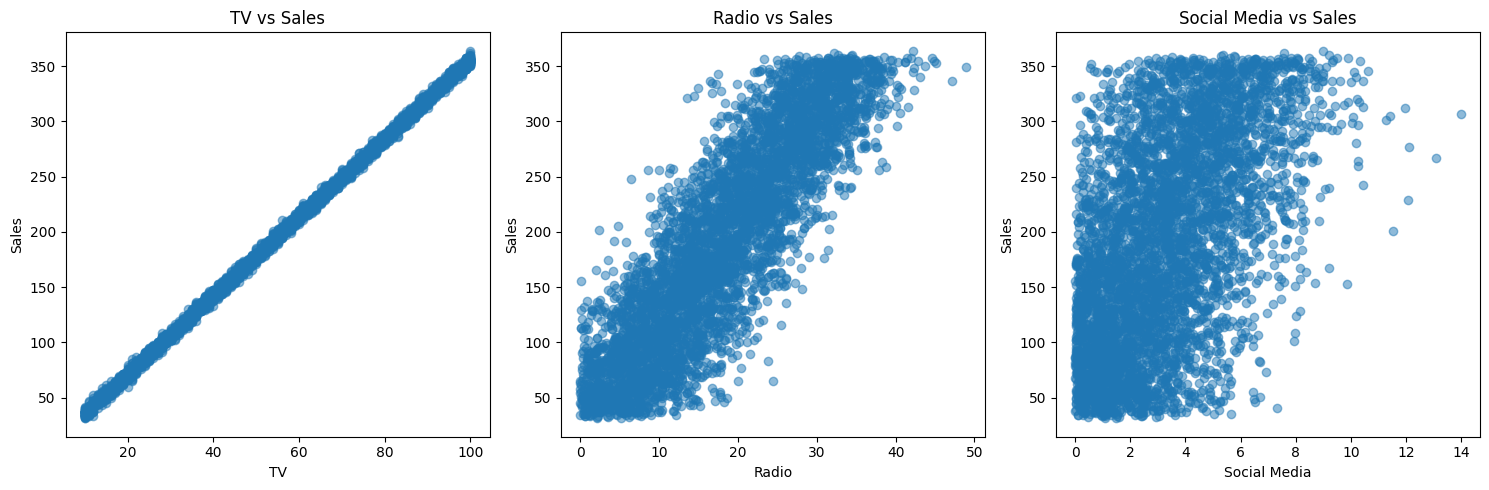

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['TV', 'Radio', 'Social Media']):
    axes[i].scatter(df[col], df['Sales'], alpha=0.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Sales")
    axes[i].set_title(f"{col} vs Sales")

plt.tight_layout()
plt.show()

TV est le prédicteur dominant des ventes. La régression linéaire sera déjà très performante.  
L'effet de Radio sur les ventes existe mais est secondaire. 
Social Media seul n'explique pas les ventes.  
TV sera la variable la plus importante dans tous les modèles.



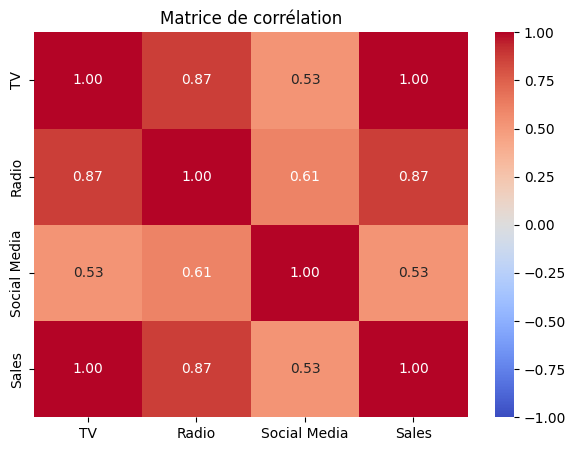

In [13]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[['TV', 'Radio', 'Social Media', 'Sales']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1
)
plt.title("Matrice de corrélation")
plt.show()

TV et Sales : correlation parfaite.   
Radio et Sales : correlation correcte.  
Social Media et Sales : correlation pas top. 

In [14]:
df['budget_total'] = df['TV'] + df['Radio'] + df['Social Media']
df['ROI'] = df['Sales'] / df['budget_total']

for col in ['budget_total', 'ROI']:
    print(f"Corrélation {col} / Sales : {df[col].corr(df['Sales']):.3f}")

Corrélation budget_total / Sales : 0.987
Corrélation ROI / Sales : 0.135
